**REPORT-1 : Exploration , data visualization and data pre-processing Report**

**Project Grp : mar26_bds_int_co2**

**CO2 Emissions Prediction: Data Preprocessing**

Author : Nithin K, Romeal N , Sied

**Introduction**
Climate change mitigation is a global priority, with transportation being a major source of CO₂ emissions. This project focuses on predicting vehicle emissions in France using 2013 homologation data from UTAC/ADEME, which includes features like fuel type, hybrid type, vehicle mass, gearbox, and fuel consumption. Various machine learning models ( XYZ - in progress.....tbd) are used to estimate emissions based on these characteristics. The predictions are then linked to France’s EEA database of total vehicles produced untill 2024 , to predict which of the models  tied to emission levels.<br>

This project report  analyzes CO2 emissions from vehicles registered in Europe, primarily using EEA data from 2024, to identify technical factors driving pollution and enable predictive modeling for new vehicle series.


**Project Scope**
 
This notebook is part-1  of a ML  project 1 that aims to build a predictive model for CO2 emission of cars registered in France in 2024.

The dataset includes : 

- Fuel consumption,
- CO2 emissions,
- Car make , type , fuel used etc 
- Vehicle technical characteristics (brand, model, engine type, etc)

The goal of this notebook is to:
- Download & load the dataset,
- Perform initial exploration,
- Visualize, Manipulate and generates loigcal Plots
- Clean and preprocess the data for modeling,
- Analyze factors influencing CO2 emissions (g/km) in vehicles.


**Dataset Overview**

   **Title:**

   **[2024] Monitoring of CO2 emissions from passenger cars Regulation (EU) 2019/631e**

   📍 Available on https://www.eea.europa.eu/en/datahub/datahubitem-view/fa8b1229-3db6-495d-b18e-9c9b3267c02b 
   
   📄 Accompanied by a Table definition for all the variables : **Table definition**


**Context**

The data comes from the **European Environment Agency**, based on the **Monitoring of CO2 emissions from passenger cars Regulation (EU) 2019/631** report datahub.


The EEA’s knowledge work relies on high-quality data. Through our network and other institutional partners across 38 European countries, they collect, quality-assure and quality-check data on a wide set of topics and legislation related to the environment, climate and sustainability. 

The Regulation (EU) No 2019/631 requires Countries to record information for each new passenger car registered in its territory. Every year, each Member State shall submit to the Commission all the information related to their new registrations. In particular, the following details are required for each new passenger car registered: manufacturer name, type approval number, type, variant, version, make and commercial name, specific emissions of CO2 (NEDC and WLTP protocols), masses of the vehicle, wheel base, track width, engine capacity and power, fuel type and mode, eco-innovations and electricity consumption

**Dataset Update** : Initially the dataset contained 10779681 entries/rows with 40 colums measuring upto 3.2GB.Upon close inspection,several duplicate rows were identified and removed to ensure good data quality.<br>
After the deduplication process, the dataset was reduced to 10779681 rows with 16 colums omeasuring upto 880Mb.


In [2]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
#df = pd.read_csv('data.csv',sep=',',low_memory=False) 
df = pd.read_csv('data.csv',sep=',')
df.head()


C:\Users\nithinkarkal\AppData\Local\Temp\ipykernel_1636\2801947973.py:2: DtypeWarning: Columns (0: VFN, 1: IT, 2: ech, 3: RLFI) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data.csv',sep=',')


,ID,Country,VFN,Mp,Mh,Man,MMS,Tan,T,Va,...,Erwltp (g/km),De,Vf,Status,year,Date of registration,Fuel consumption,ech,RLFI,Electric range (km)
0,148534149,NL,IP-C519_2022_00007-WF0-1,FORD,FORD WERKE GMBH,FORD-WERKE GMBH,NaN,e13*2007/46*1911*17,DEH,R0DB1PX,...,2.1,NaN,NaN,P,2024,2024-01-05,5.3,EURO 6 EA,RL-C519_2019_00001-WF0-0,NaN
1,148534150,NL,IP-ZKU____REDU7G61-VF3,STELLANTIS,AUTOMOBILES PEUGEOT,AUTOMOBILES PEUGEOT,NaN,e2*2007/46*0532*21,V,S,...,NaN,NaN,NaN,P,2024,2024-10-10,NaN,AX,RL-___MP2CREDU7761-VR3,343.0
2,148534151,NL,IP-2023_225H4D-YV1-1,VOLVO CARS POLESTAR SUZUKI,VOLVO,VOLVO CAR CORPORATION,NaN,e4*2007/46*1315*21,Z,ZSH4,...,NaN,NaN,NaN,P,2024,2024-07-30,0.7,EURO 6 EA,RL-2347SPALO22XDVX-YV1-1,93.0
3,148534152,NL,IP-C519_2022_00007-WF0,FORD,FORD WERKE GMBH,FORD-WERKE GMBH,NaN,e13*2007/46*1911*18,DEH,R0DB1PX,...,2.1,NaN,NaN,P,2024,2024-05-29,5.4,EURO 6 EA,RL-C519_2019_00001-WF0,NaN
4,148534153,NL,IP-0165-JT1,SUBARU-MAZDA-TOYOTA,TOYOTA MOTOR CORPORATION,TOYOTA MOTOR CORPORATION,NaN,e6*2018/858*00060*03,AB7(JP),KGB70(H),...,NaN,NaN,NaN,P,2024,2024-11-29,4.8,EURO 6 EA,RL-0060-JT1,NaN


In [4]:
# check data types

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10779681 entries, 0 to 10779680
Data columns (total 40 columns):
 #   Column                Dtype  
---  ------                -----  
 0   ID                    int64  
 1   Country               str    
 2   VFN                   str    
 3   Mp                    str    
 4   Mh                    str    
 5   Man                   str    
 6   MMS                   float64
 7   Tan                   str    
 8   T                     str    
 9   Va                    str    
 10  Ve                    str    
 11  Mk                    str    
 12  Cn                    str    
 13  Ct                    str    
 14  Cr                    str    
 15  r                     int64  
 16  m (kg)                float64
 17  Mt                    float64
 18  Enedc (g/km)          float64
 19  Ewltp (g/km)          float64
 20  W (mm)                float64
 21  At1 (mm)              float64
 22  At2 (mm)              float64
 23  Ft              

Total size of the 1st data set 

In [5]:
# check data shape
df.shape

(10779681, 40)

In [6]:
# check column names
df.columns

Index(['ID', 'Country', 'VFN', 'Mp', 'Mh', 'Man', 'MMS', 'Tan', 'T', 'Va',
       'Ve', 'Mk', 'Cn', 'Ct', 'Cr', 'r', 'm (kg)', 'Mt', 'Enedc (g/km)',
       'Ewltp (g/km)', 'W (mm)', 'At1 (mm)', 'At2 (mm)', 'Ft', 'Fm',
       'ec (cm3)', 'ep (KW)', 'z (Wh/km)', 'IT', 'Ernedc (g/km)',
       'Erwltp (g/km)', 'De', 'Vf', 'Status', 'year', 'Date of registration',
       'Fuel consumption ', 'ech', 'RLFI', 'Electric range (km)'],
      dtype='str')

In [7]:
#Statistical Summary (Numerical)
df.describe()

,ID,MMS,r,m (kg),Mt,Enedc (g/km),Ewltp (g/km),W (mm),At1 (mm),At2 (mm),ec (cm3),ep (KW),z (Wh/km),Ernedc (g/km),Erwltp (g/km),De,Vf,year,Fuel consumption,Electric range (km)
count,1.077968e+07,0.0,10779681.0,1.077916e+07,1.046366e+07,0.0,1.075818e+07,0.0,0.0,0.0,9.209781e+06,1.075620e+07,2.266911e+06,0.0,5.344003e+06,0.0,0.0,10779681.0,8.917600e+06,2.239573e+06
mean,1.521201e+08,NaN,1.0,1.560132e+03,1.668003e+03,NaN,1.068796e+02,NaN,NaN,NaN,1.546410e+03,1.166188e+02,1.742220e+02,NaN,1.485387e+00,NaN,NaN,2024.0,5.440701e+00,3.410387e+02
std,5.495697e+06,NaN,0.0,3.656444e+02,3.795869e+02,NaN,5.793564e+01,NaN,NaN,NaN,5.256672e+02,6.434538e+01,3.203508e+01,NaN,5.308568e-01,NaN,NaN,0.0,1.712833e+00,2.015277e+02
min,1.375920e+08,NaN,1.0,5.130000e+02,3.170000e+02,NaN,0.000000e+00,NaN,NaN,NaN,6.580000e+02,8.000000e+00,1.100000e+01,NaN,5.000000e-01,NaN,NaN,2024.0,1.000000e-01,1.100000e+01
25%,1.478111e+08,NaN,1.0,1.280000e+03,1.381000e+03,NaN,1.010000e+02,NaN,NaN,NaN,1.199000e+03,7.400000e+01,1.560000e+02,NaN,1.000000e+00,NaN,NaN,2024.0,4.900000e+00,9.100000e+01
50%,1.511922e+08,NaN,1.0,1.484000e+03,1.590000e+03,NaN,1.230000e+02,NaN,NaN,NaN,1.498000e+03,1.000000e+02,1.690000e+02,NaN,1.700000e+00,NaN,NaN,2024.0,5.500000e+00,4.200000e+02
75%,1.575069e+08,NaN,1.0,1.773000e+03,1.892000e+03,NaN,1.370000e+02,NaN,NaN,NaN,1.968000e+03,1.310000e+02,1.810000e+02,NaN,1.960000e+00,NaN,NaN,2024.0,6.100000e+00,5.140000e+02
max,1.610627e+08,NaN,1.0,4.800000e+03,4.574000e+03,NaN,5.430000e+02,NaN,NaN,NaN,7.750000e+03,1.352000e+03,5.940000e+02,NaN,3.600000e+00,NaN,NaN,2024.0,2.700000e+01,8.830000e+02


In [8]:
#Statistical Summary (Categorical)
df.describe(include='object')

C:\Users\nithinkarkal\AppData\Local\Temp\ipykernel_1636\1285481591.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Country,VFN,Mp,Mh,Man,Tan,T,Va,Ve,Mk,Cn,Ct,Cr,Ft,Fm,IT,Status,Date of registration,ech,RLFI
count,10779681,10407166,10092977,10779681,10779681,10778734,10771437,10749517,10713658,10779360,10779273,10769989,10779681,10779681,10779662,5377503,10779681,10779681,10572534,6538956
unique,29,7746,11,116,115,7253,2047,5037,24191,497,7390,8,2,10,6,159,1,366,133,4200
top,DE,IP-03_312_0344-ZFA-1,VOLKSWAGEN,VOLKSWAGEN,VOLKSWAGEN AG,e19*2007/46*0026*23,U,P,MT,TOYOTA,SANDERO,M1,M1,petrol,M,E2 29 37,P,2024-06-28,EURO 6 EA,RL-DQ200_7F_17_012-WVW-1
freq,2728237,180041,2833686,1159715,1159974,135104,619096,336131,94361,818353,258794,10690648,10705540,6444362,4766067,901657,10779681,118169,3332030,112563


In [9]:
# checking for missing values Count in each column
df.isnull().sum()


ID                             0
Country                        0
VFN                       372515
Mp                        686704
Mh                             0
Man                            0
MMS                     10779681
Tan                          947
T                           8244
Va                         30164
Ve                         66023
Mk                           321
Cn                           408
Ct                          9692
Cr                             0
r                              0
m (kg)                       519
Mt                        316019
Enedc (g/km)            10779681
Ewltp (g/km)               21497
W (mm)                  10779681
At1 (mm)                10779681
At2 (mm)                10779681
Ft                             0
Fm                            19
ec (cm3)                 1569900
ep (KW)                    23481
z (Wh/km)                8512770
IT                       5402178
Ernedc (g/km)           10779681
Erwltp (g/

In [10]:
#Missing Values Percentage coulumn-wise 
# arrange it in a descending order and print it 

missing_values = (df.isnull().sum() / len(df)) * 100
missing_values = missing_values[missing_values > 0]
missing_values.sort_values(ascending=False, inplace=True)
print(missing_values)



MMS                    100.000000
Enedc (g/km)           100.000000
Ernedc (g/km)          100.000000
At2 (mm)               100.000000
At1 (mm)               100.000000
W (mm)                 100.000000
Vf                     100.000000
De                     100.000000
Electric range (km)     79.224125
z (Wh/km)               78.970519
Erwltp (g/km)           50.425221
IT                      50.114451
RLFI                    39.339986
Fuel consumption        17.273990
ec (cm3)                14.563511
Mp                       6.370355
VFN                      3.455715
Mt                       2.931617
ech                      1.921643
Ve                       0.612476
Va                       0.279823
ep (KW)                  0.217826
Ewltp (g/km)             0.199421
Ct                       0.089910
T                        0.076477
Tan                      0.008785
m (kg)                   0.004815
Cn                       0.003785
Mk                       0.002978
Fm            

**Drop 100% missing value Colums**

In [11]:
# drop columns with 100% missing values
df.drop(columns=missing_values[missing_values == 100].index, inplace=True)  


In [12]:
#check for duplicates & print the number of duplicates
duplicates = df.duplicated().sum()
print("Number of duplicates:", duplicates)  



Number of duplicates: 0


In [13]:
df.nunique()

ID                      10779681
Country                       29
VFN                         7746
Mp                            11
Mh                           116
Man                          115
Tan                         7253
T                           2047
Va                          5037
Ve                         24191
Mk                           497
Cn                          7390
Ct                             8
Cr                             2
r                              1
m (kg)                      2283
Mt                          2198
Ewltp (g/km)                 422
Ft                            10
Fm                             6
ec (cm3)                     275
ep (KW)                      432
z (Wh/km)                    389
IT                           159
Erwltp (g/km)                211
Status                         1
year                           1
Date of registration         366
Fuel consumption             189
ech                          133
RLFI      

**1 value columns**

In [14]:
# print sample 20 data from the columns which have only 1 unique value
for col in df.columns:
    if df[col].nunique() == 1:
        print(f"Column: {col}")
        print(df[col].sample(5))
        print("\n")

Column: r
10615904    1
2460366     1
5335624     1
700724      1
9088319     1
Name: r, dtype: int64


Column: Status
10697157    P
4415485     P
5742542     P
1613804     P
3100622     P
Name: Status, dtype: str


Column: year
7936409    2024
4852367    2024
3599925    2024
4330588    2024
3335565    2024
Name: year, dtype: int64




In [15]:
#drop coumns with only 1 unique value
for col in df.columns:
    if df[col].nunique() == 1:
        df.drop(columns=col, inplace=True)      

In [16]:
#Statistical Summary (Numerical)
df.describe()

,ID,m (kg),Mt,Ewltp (g/km),ec (cm3),ep (KW),z (Wh/km),Erwltp (g/km),Fuel consumption,Electric range (km)
count,1.077968e+07,1.077916e+07,1.046366e+07,1.075818e+07,9.209781e+06,1.075620e+07,2.266911e+06,5.344003e+06,8.917600e+06,2.239573e+06
mean,1.521201e+08,1.560132e+03,1.668003e+03,1.068796e+02,1.546410e+03,1.166188e+02,1.742220e+02,1.485387e+00,5.440701e+00,3.410387e+02
std,5.495697e+06,3.656444e+02,3.795869e+02,5.793564e+01,5.256672e+02,6.434538e+01,3.203508e+01,5.308568e-01,1.712833e+00,2.015277e+02
min,1.375920e+08,5.130000e+02,3.170000e+02,0.000000e+00,6.580000e+02,8.000000e+00,1.100000e+01,5.000000e-01,1.000000e-01,1.100000e+01
25%,1.478111e+08,1.280000e+03,1.381000e+03,1.010000e+02,1.199000e+03,7.400000e+01,1.560000e+02,1.000000e+00,4.900000e+00,9.100000e+01
50%,1.511922e+08,1.484000e+03,1.590000e+03,1.230000e+02,1.498000e+03,1.000000e+02,1.690000e+02,1.700000e+00,5.500000e+00,4.200000e+02
75%,1.575069e+08,1.773000e+03,1.892000e+03,1.370000e+02,1.968000e+03,1.310000e+02,1.810000e+02,1.960000e+00,6.100000e+00,5.140000e+02
max,1.610627e+08,4.800000e+03,4.574000e+03,5.430000e+02,7.750000e+03,1.352000e+03,5.940000e+02,3.600000e+00,2.700000e+01,8.830000e+02


In [17]:
#Statistical Summary (Categorical)
df.describe(include='object')

C:\Users\nithinkarkal\AppData\Local\Temp\ipykernel_1636\1285481591.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Country,VFN,Mp,Mh,Man,Tan,T,Va,Ve,Mk,Cn,Ct,Cr,Ft,Fm,IT,Date of registration,ech,RLFI
count,10779681,10407166,10092977,10779681,10779681,10778734,10771437,10749517,10713658,10779360,10779273,10769989,10779681,10779681,10779662,5377503,10779681,10572534,6538956
unique,29,7746,11,116,115,7253,2047,5037,24191,497,7390,8,2,10,6,159,366,133,4200
top,DE,IP-03_312_0344-ZFA-1,VOLKSWAGEN,VOLKSWAGEN,VOLKSWAGEN AG,e19*2007/46*0026*23,U,P,MT,TOYOTA,SANDERO,M1,M1,petrol,M,E2 29 37,2024-06-28,EURO 6 EA,RL-DQ200_7F_17_012-WVW-1
freq,2728237,180041,2833686,1159715,1159974,135104,619096,336131,94361,818353,258794,10690648,10705540,6444362,4766067,901657,118169,3332030,112563


**TARGET** : 
- Ewltp (g/km) : 0.2% missing value , hence drop the NaN values
- Erwltp (g/km)  : more than 50% missing value----> drop Erwltp 

In [18]:
#drop missing values in Ewltp (g/km)
df.dropna(subset=["Ewltp (g/km)"], inplace=True)    

#drop Erwltp (g/km) column as it has more than 50%   missing values
df.drop(columns=["Erwltp (g/km)"], inplace=True)

#checking for missing values Count in each column
df.isnull().sum()


ID                            0
Country                       0
VFN                      359208
Mp                       676232
Mh                            0
Man                           0
Tan                         892
T                          7754
Va                        23976
Ve                        57474
Mk                          219
Cn                          254
Ct                         9647
Cr                            0
m (kg)                      512
Mt                       304116
Ewltp (g/km)                  0
Ft                            0
Fm                           15
ec (cm3)                1569362
ep (KW)                   23199
z (Wh/km)               8491786
IT                      5380997
Date of registration          0
Fuel consumption        1845295
ech                      206016
RLFI                    4225279
Electric range (km)     8519040
dtype: int64

# -------------------------------------------------------------------

### drop ID,VFN,Mp,Man,Ve,Ct
### col_to_be_dropped = ["ID","VFN", "Mp", "Man","Tan","T","Ve", "Cr"]


**Find and group irrelvant columns** : needs to be dropped
- ID  : 10779681 unique values . Not useful data for ML prediction.
- VFN : 7746 uniques . Not useful . Looks to be an internal coding for identification. with more 350000 missing values.
- Mp,Mh,Man : seems to have same or similar data. But Mh seems to be clean , with no NaN, full data availability. Hence drop Mp, Man.
- TAN , T : ~7000 & ~4000 uniques . Cannot be categorised and used. Drop TAN ,T . Also no useful data for ML
- Ve,Va : Va (variant) is present of the Manufacturer. To reduce the corelation. Ve is dropped. since it give version for evry variant.  Brand--->Variant(suffice) --->Version(dropped) ??
- "Cn","Ct","Cr  : Cr is the subset of Ct. ( hence drop Cr) + Cn to be retained . Can be seen in the uniques.

# -------------------------------------------------------------------

**Verification and checking cells below**  + Colums are dropped at the end of verification and checking

In [19]:
# display Mp & Mh 
df[["Mh","Va","Ve","Tan","T"]].head(5)

,Mh,Va,Ve,Tan,T
0,FORD WERKE GMBH,R0DB1PX,5APCENA5IBS,e13*2007/46*1911*17,DEH
1,AUTOMOBILES PEUGEOT,S,ZKUZ-37B0GN,e2*2007/46*0532*21,V
2,VOLVO,ZSH4,ZSH4VD0?,e4*2007/46*1315*21,Z
3,FORD WERKE GMBH,R0DB1PX,5APCENA5IBS,e13*2007/46*1911*18,DEH
4,TOYOTA MOTOR CORPORATION,KGB70(H),KGB70L-AHMNKW(2D),e6*2018/858*00060*03,AB7(JP)


In [20]:
# display  Va column with missing values of Va
df[df["Va"].isnull()][["Mh","Va","Ve"]].head(5)

,Mh,Va,Ve
67230,AA-IVA,NaN,NaN
67252,AA-IVA,NaN,NaN
67319,AA-IVA,NaN,NaN
67349,AA-IVA,NaN,NaN
67358,AA-IVA,NaN,NaN


In [21]:
# display me the rows from Mh column with AA-IVA data without NaN values in Va column
df[(df["Mh"] == "AA-IVA") & (df["Va"].notnull())][["Mh","Va","Ve"]].head(5)

,Mh,Va,Ve
76485,AA-IVA,FM,00M9SW51A3J2T0
79728,AA-IVA,GXE,C2L
95286,AA-IVA,BT9,C1L
112542,AA-IVA,BT9,C1L
563458,AA-IVA,22CF,NaN


In [22]:
#  fill NaN values in Va column with mode corresponding to value in Mh column 
df["Va"] = df.groupby("Mh")["Va"].transform(lambda x: x.fillna(x.mode()[0]))

In [23]:
# display  Va column with missing values of Va
df[df["Va"].isnull()][["Mh","Va","Ve"]].head(5)

,Mh,Va,Ve


In [24]:
# display missing MK values along with its corresponding Mh values
df[df["Mk"].isnull()][["Mh","Mk"]].head(5)


,Mh,Mk
572415,MORGAN,NaN
634556,OUT OF SCOPE,NaN
639986,DFSK,NaN
648003,CHERY,NaN
654565,AA-IVA,NaN


In [25]:
# For missing Mk values we can fill it with the mode value of Mk for the corresponding Mh group
df["Mk"] = df.groupby("Mh")["Mk"].transform(lambda x: x.fillna(x.mode()[0]))

#display Mh & Mk values for OUT OF SCOPE,DFSK,AA-IVA,CHERY
df[df["Mh"].isin(["OUT OF SCOPE","DFSK","AA-IVA","CHERY"])][["Mh","Mk"]].head(10)

,Mh,Mk
20552,DFSK,DFSK
43184,CHERY,OMODA
51391,CHERY,OMODA
64969,DFSK,DFSK
67230,AA-IVA,SUBARU
67252,AA-IVA,SUBARU
67319,AA-IVA,SUBARU
67349,AA-IVA,SUBARU
67358,AA-IVA,INEOS
67363,AA-IVA,SUBARU


In [26]:
# display sample for these columns ,Cn,Ct,Cr alogn with Mh column
df[["Mh","Cn","Ct","Cr"]].head(10)
       

,Mh,Cn,Ct,Cr
0,FORD WERKE GMBH,FOCUS,M1,M1
1,AUTOMOBILES PEUGEOT,VIVARO,M1,M1
2,VOLVO,S60,M1,M1
3,FORD WERKE GMBH,FOCUS,M1,M1
4,TOYOTA MOTOR CORPORATION,TOYOTA AYGO X,M1,M1
5,DACIA,SANDERO,M1,M1
6,VOLKSWAGEN,TIGUAN,M1,M1
7,VOLKSWAGEN,TAIGO,M1,M1
8,VOLVO,C40,M1,M1
9,VOLVO,XC60,M1,M1


In [27]:
# For missing Cn values we can fill it with the mode value of Cn for the corresponding Mh group
df["Cn"] = df.groupby("Mh")["Cn"].transform(lambda x: x.fillna(x.mode()[0]))

In [28]:
# For missing Ct values we can fill it with the mode value of Ct for the corresponding Cr group
df["Ct"] = df.groupby("Cr")["Ct"].transform(lambda x: x.fillna(x.mode()[0]))

In [29]:
#display count of missing values in Cn Ct and Cr columns
df[["Cn","Ct","Cr"]].isnull().sum()

Cn    0
Ct    0
Cr    0
dtype: int64

In [30]:
#display uniques for Cn,Ct,Cr columns
df[["Cn","Ct","Cr"]].nunique()

Cn    7026
Ct       8
Cr       2
dtype: int64

In [31]:
# display unique values for Ct and Cr columns
print("Unique values in Ct column:")
print(df["Ct"].unique())    
print("Unique values in Cr column:")
print(df["Cr"].unique())

Unique values in Ct column:
<StringArray>
['M1', 'M1G', 'N2', 'N1', 'N1G', 'm1', 'n2', 'n1']
Length: 8, dtype: str
Unique values in Cr column:
<StringArray>
['M1', 'M1G']
Length: 2, dtype: str


In [32]:
# describe the m (kg) column and Mt
df[["m (kg)","Mt"]].describe()

#replace missing values in m (kg) column with median value of m (kg) column
df["m (kg)"] = df["m (kg)"].fillna(df["m (kg)"].median())

#replace missing values in Mt column with median value of Mt column
df["Mt"] = df["Mt"].fillna(df["Mt"].median())


# dropped many columns here 

In [33]:
# drop the following columns ID,VFN, Mp, Man, Tan, T, Ve, Cr        
col_to_be_dropped = ["ID","VFN", "Mp", "Man","Tan","T","Ve", "Cr"]
df = df.drop(col_to_be_dropped, axis=1)    

In [34]:
#display sample data for Ft and Fm columns
df[["Ft","Fm"]].head(5)

# display NaN values of Fm and corresponding Mh , Ft values
df[df["Fm"].isnull()][["Mh","Ft","Fm"]].head(5)

,Mh,Ft,Fm
731242,AA-IVA,unknown,NaN
749137,AA-IVA,unknown,NaN
795537,AA-IVA,unknown,NaN
1237941,AA-IVA,unknown,NaN
1439564,AA-IVA,unknown,NaN


In [35]:
# For missing Fm values we can fill it with the mode value of Fm for the corresponding Mh group 
df["Fm"] = df.groupby("Mh")["Fm"].transform(lambda x: x.fillna(x.mode()[0]))

# dropped RLFI below

In [36]:
#drop RLFI column as it has more than 50% missing values
df.drop(columns=["RLFI"], inplace=True)

In [37]:
# fill IT = EV , if Ft = electric
df.loc[df["Ft"] == "electric", "IT"] = "EV"

In [38]:
# convert Date of registration column to datetime format and create a new column for month and day
df["Date of registration"] = pd.to_datetime(df["Date of registration"], errors='coerce')    
df["Month"] = df["Date of registration"].dt.month
df["Day"] = df["Date of registration"].dt.day

In [39]:
#drop Date of registration column as we have extracted month and day from it
df.drop(columns=["Date of registration"], inplace=True)

# looking / display / print 

In [40]:
#checking for missing values Count in each column
df.isnull().sum()

Country                      0
Mh                           0
Va                           0
Mk                           0
Cn                           0
Ct                           0
m (kg)                       0
Mt                           0
Ewltp (g/km)                 0
Ft                           0
Fm                           0
ec (cm3)               1569362
ep (KW)                  23199
z (Wh/km)              8491786
IT                     3812431
Fuel consumption       1845295
ech                     206016
Electric range (km)    8519040
Month                        0
Day                          0
dtype: int64

In [41]:
#display unique values for Ft column and Fm column
print("Unique values in Ft column:")
print(df["Ft"].unique())    
print("Unique values in Fm column:")
print(df["Fm"].unique())    

Unique values in Ft column:
<StringArray>
[         'petrol',        'electric', 'petrol/electric',             'lpg',
 'diesel/electric',          'diesel',             'e85',              'ng',
        'hydrogen',         'unknown']
Length: 10, dtype: str
Unique values in Fm column:
<StringArray>
['H', 'E', 'P', 'M', 'B', 'F']
Length: 6, dtype: str


In [42]:
#display sample values for "ec (cm3)" column which is not NaN
df[df["ec (cm3)"].notnull()].head(5)

,Country,Mh,Va,Mk,Cn,Ct,m (kg),Mt,Ewltp (g/km),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),IT,Fuel consumption,ech,Electric range (km),Month,Day
0,NL,FORD WERKE GMBH,R0DB1PX,FORD,FOCUS,M1,1440.0,1523.0,121.0,petrol,H,999.0,92.0,NaN,E13 32 37,5.3,EURO 6 EA,NaN,1,5
2,NL,VOLVO,ZSH4,VOLVO,S60,M1,2039.0,2176.0,16.0,petrol/electric,P,1969.0,186.0,163.0,NaN,0.7,EURO 6 EA,93.0,7,30
3,NL,FORD WERKE GMBH,R0DB1PX,FORD,FOCUS,M1,1466.0,1549.0,123.0,petrol,H,999.0,92.0,NaN,E13 32 37,5.4,EURO 6 EA,NaN,5,29
4,NL,TOYOTA MOTOR CORPORATION,KGB70(H),TOYOTA,TOYOTA AYGO X,M1,1020.0,1088.0,108.0,petrol,M,998.0,53.0,NaN,NaN,4.8,EURO 6 EA,NaN,11,29
5,NL,DACIA,BEV,DACIA,SANDERO,M1,1181.0,1262.0,125.0,petrol,M,999.0,81.0,NaN,E19 29 37,5.5,EURO 6 AP,NaN,5,29


In [43]:
#display the sample data  missing values in "ec (cm3)" column
df[df["ec (cm3)"].isnull()].head(5)


,Country,Mh,Va,Mk,Cn,Ct,m (kg),Mt,Ewltp (g/km),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),IT,Fuel consumption,ech,Electric range (km),Month,Day
1,NL,AUTOMOBILES PEUGEOT,S,OPEL,VIVARO,M1,2267.0,2454.0,0.0,electric,E,NaN,100.0,244.0,EV,NaN,AX,343.0,10,10
8,NL,VOLVO,XKEH,VOLVO,C40,M1,2095.0,2203.0,0.0,electric,E,NaN,185.0,166.0,EV,NaN,AX,570.0,12,7
10,NL,VOLVO,2ZEM,VOLVO,EX30,M1,1840.0,1937.0,0.0,electric,E,NaN,200.0,172.0,EV,NaN,AX,334.0,11,29
14,NL,TESLA,Y7CR,TESLA,MODEL Y,M1,1992.0,2095.0,0.0,electric,E,NaN,235.0,157.0,EV,NaN,AX,455.0,11,15
15,NL,HYUNDAI,F5E62,HYUNDAI,IONIQ5,M1,2010.0,2165.0,0.0,electric,E,NaN,168.0,170.0,EV,NaN,AX,507.0,2,16


In [44]:
#display the sample data for missing values in ep (kW) column
df[df["ep (KW)"].isnull()].head(5)


,Country,Mh,Va,Mk,Cn,Ct,m (kg),Mt,Ewltp (g/km),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),IT,Fuel consumption,ech,Electric range (km),Month,Day
870758,DE,MERCEDES-BENZ AG,71ETB1,MERCEDES-BENZ,AMG EQS 53 4MATIC+,M1,2715.0,2895.0,0.0,electric,E,NaN,NaN,217.0,EV,NaN,AX,605.0,3,21
1019561,DE,AA-IVA,6SEAT,YUEDA HUMAN HORIZONS,HIPHI X,M1,2730.0,1589.0,0.0,electric,E,NaN,NaN,NaN,EV,NaN,3644F,NaN,1,24
1418183,DE,AA-IVA,HL,FALLER,OUTBACK,M1,900.0,1589.0,0.0,electric,E,NaN,NaN,NaN,EV,NaN,0088,NaN,8,21
1569125,ES,SUZUKI MOTOR CORPORATION,CEDS,SUZUKI,SWIFT,M1,1032.0,1109.0,106.0,petrol,H,1197.0,NaN,NaN,NaN,4.7,EURO 6 EA,NaN,12,23
1570202,ES,SUZUKI MOTOR CORPORATION,CEDS,SUZUKI,SWIFT,M1,994.0,1086.0,99.0,petrol,H,1197.0,NaN,NaN,NaN,4.4,EURO 6 EA,NaN,12,9


In [45]:
df.info()



<class 'pandas.DataFrame'>
Index: 10758184 entries, 0 to 10779680
Data columns (total 20 columns):
 #   Column               Dtype  
---  ------               -----  
 0   Country              str    
 1   Mh                   str    
 2   Va                   str    
 3   Mk                   str    
 4   Cn                   str    
 5   Ct                   str    
 6   m (kg)               float64
 7   Mt                   float64
 8   Ewltp (g/km)         float64
 9   Ft                   str    
 10  Fm                   str    
 11  ec (cm3)             float64
 12  ep (KW)              float64
 13  z (Wh/km)            float64
 14  IT                   str    
 15  Fuel consumption     float64
 16  ech                  str    
 17  Electric range (km)  float64
 18  Month                int32  
 19  Day                  int32  
dtypes: float64(8), int32(2), str(10)
memory usage: 1.6 GB


**Classify Vehicle type** : since we have mutually exclusive features such 
- ec3 & Fuel consumption = NaNs for EVs
- z & Electrci range = NaN for ICE

In [46]:
def map_vehicle_type(ft):
    if ft == 'electric':
        return 'EV'
    elif 'electric' in str(ft):
        return 'Hybrid'
    elif ft in ['hydrogen']:
        return 'Hydrogen'  
    elif ft in ['petrol', 'diesel', 'lpg', 'e85', 'ng']:
        return 'ICE'
    else:
        return 'Unknown'

df['vehicle_type'] = df['Ft'].apply(map_vehicle_type)

In [47]:
df['vehicle_type'].value_counts()

vehicle_type
ICE         8418571
EV          1568577
Hybrid       770300
Hydrogen        721
Unknown          15
Name: count, dtype: int64

In [48]:
# NaNs in vehcile_type column
df.loc[df['vehicle_type']=='ICE', ['z (Wh/km)', 'Electric range (km)']] = 0
df.loc[df['vehicle_type']=='EV', ['ec (cm3)', 'Fuel consumption ']] = 0
df.loc[df['vehicle_type']=='Hydrogen', ['ec (cm3)']] = 0

In [49]:
# Fill rest of the ec (cm3) values with mean of corresponding Ft group

df['ec (cm3)'] = df['ec (cm3)'].fillna(
    df.groupby('Ft')['ec (cm3)'].transform('mean')
)

In [50]:
df['ep (KW)'] = df['ep (KW)'].fillna(
    df.groupby('vehicle_type')['ep (KW)'].transform('mean')
)

#df['ep (KW)'] = df['ep (KW)'].fillna(df['ep (KW)'].median())

In [51]:
#median by vehicle type is more robust than mean, especially since z (Wh/km) can have outliers. So we will fill NaN values in z (Wh/km) column with median of corresponding vehicle type group.

df['z (Wh/km)'] = df['z (Wh/km)'].fillna(
    df.groupby('vehicle_type')['z (Wh/km)'].transform('median')
)

In [52]:
# Sinc there are no values for "Z (Wh/km)" for Hydrogen & Unknown. We will fill 0 for these values in z (Wh/km) column
df.loc[df['vehicle_type'].isin(['Hydrogen', 'Unknown']), 'z (Wh/km)'] = 0

In [53]:
# Step 2: Fill remaining NaNs using median per vehicle_type
df['Fuel consumption '] = df['Fuel consumption '].fillna(
    df.groupby('vehicle_type')['Fuel consumption '].transform('median')
)

# Step 3: Fallback (if anything still missing)
df['Fuel consumption '] = df['Fuel consumption '].fillna(
    df['Fuel consumption '].median()
)

In [54]:
# Step 2: Fill remaining NaNs using median per vehicle_type
df['Electric range (km)'] = df['Electric range (km)'].fillna(
    df.groupby('vehicle_type')['Electric range (km)'].transform('median')
)

# Step 3: Fallback (if anything still missing)
df['Electric range (km)'] = df['Electric range (km)'].fillna(
    df['Electric range (km)'].median()
)

In [55]:
df.isnull().sum()

Country                      0
Mh                           0
Va                           0
Mk                           0
Cn                           0
Ct                           0
m (kg)                       0
Mt                           0
Ewltp (g/km)                 0
Ft                           0
Fm                           0
ec (cm3)                     0
ep (KW)                      0
z (Wh/km)                    0
IT                     3812431
Fuel consumption             0
ech                     206016
Electric range (km)          0
Month                        0
Day                          0
vehicle_type                 0
dtype: int64

**ECH treatment**

In [56]:
import re

def extract_euro(x):
    if pd.isna(x):
        return "UNKNOWN"
    
    x = x.upper()
    
    match = re.search(r'EURO\s*(\d|VI|V|IV|III)', x)
    if match:
        val = match.group(1)
        
        # Convert Roman to numeric
        roman_map = {
            'VI': '6',
            'V': '5',
            'IV': '4',
            'III': '3'
        }
        
        val = roman_map.get(val, val)
        
        return f"EURO {val}"
    
    return "OTHER"

df["ech_clean"] = df["ech"].apply(extract_euro)
df["ech_clean"].value_counts()  


df['ech_clean'] = df['ech_clean'].fillna(
    df.groupby('vehicle_type')['ech_clean'].transform(
        lambda x: x.mode()[0] if not x.mode().empty else 'UNKNOWN'
    )
)


df.drop(columns=["ech"], inplace=True)


In [57]:
df.isnull().sum()

Country                      0
Mh                           0
Va                           0
Mk                           0
Cn                           0
Ct                           0
m (kg)                       0
Mt                           0
Ewltp (g/km)                 0
Ft                           0
Fm                           0
ec (cm3)                     0
ep (KW)                      0
z (Wh/km)                    0
IT                     3812431
Fuel consumption             0
Electric range (km)          0
Month                        0
Day                          0
vehicle_type                 0
ech_clean                    0
dtype: int64

In [58]:
df.info()

<class 'pandas.DataFrame'>
Index: 10758184 entries, 0 to 10779680
Data columns (total 21 columns):
 #   Column               Dtype  
---  ------               -----  
 0   Country              str    
 1   Mh                   str    
 2   Va                   str    
 3   Mk                   str    
 4   Cn                   str    
 5   Ct                   str    
 6   m (kg)               float64
 7   Mt                   float64
 8   Ewltp (g/km)         float64
 9   Ft                   str    
 10  Fm                   str    
 11  ec (cm3)             float64
 12  ep (KW)              float64
 13  z (Wh/km)            float64
 14  IT                   str    
 15  Fuel consumption     float64
 16  Electric range (km)  float64
 17  Month                int32  
 18  Day                  int32  
 19  vehicle_type         str    
 20  ech_clean            str    
dtypes: float64(8), int32(2), str(11)
memory usage: 1.7 GB


In [59]:
#display unique values of IT    column
print("Unique values in IT column:")
print(df["IT"].unique())

Unique values in IT column:
<StringArray>
[   'E13 32 37',           'EV',            nan,    'E19 29 37',
       'E13 29',        'E9 37',        'E2 37',     'E9 29 37',
     'E2 29 37',       'E19 37',
 ...
         'E637',  'E5 29 E5 28',  'E9 29 E9 28', 'E4 32  E4 37',
 'E4 29  E4 37',      'E6 2928',   'E2 29E2 37',   'E5 28E9 32',
 'E5 29  E5 28',   'E5 37E5 32']
Length: 160, dtype: str


In [60]:
# display sample values of IT column which is not NaN
df[df["IT"].notnull()].head(5)

,Country,Mh,Va,Mk,Cn,Ct,m (kg),Mt,Ewltp (g/km),Ft,...,ec (cm3),ep (KW),z (Wh/km),IT,Fuel consumption,Electric range (km),Month,Day,vehicle_type,ech_clean
0,NL,FORD WERKE GMBH,R0DB1PX,FORD,FOCUS,M1,1440.0,1523.0,121.0,petrol,...,999.0,92.0,0.0,E13 32 37,5.3,0.0,1,5,ICE,EURO 6
1,NL,AUTOMOBILES PEUGEOT,S,OPEL,VIVARO,M1,2267.0,2454.0,0.0,electric,...,0.0,100.0,244.0,EV,0.0,343.0,10,10,EV,OTHER
3,NL,FORD WERKE GMBH,R0DB1PX,FORD,FOCUS,M1,1466.0,1549.0,123.0,petrol,...,999.0,92.0,0.0,E13 32 37,5.4,0.0,5,29,ICE,EURO 6
5,NL,DACIA,BEV,DACIA,SANDERO,M1,1181.0,1262.0,125.0,petrol,...,999.0,81.0,0.0,E19 29 37,5.5,0.0,5,29,ICE,EURO 6
7,NL,VOLKSWAGEN,ACDUSB,VOLKSWAGEN,TAIGO,M1,1229.0,1335.0,125.0,petrol,...,999.0,70.0,0.0,E13 29,5.6,0.0,10,29,ICE,EURO 6


In [61]:
#For missing IT values we can fill it with the mode value of IT for the corresponding Mk  group  
df["IT"] = df.groupby("Mk")["IT"].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else x)
)

In [62]:
df.isnull().sum()

Country                    0
Mh                         0
Va                         0
Mk                         0
Cn                         0
Ct                         0
m (kg)                     0
Mt                         0
Ewltp (g/km)               0
Ft                         0
Fm                         0
ec (cm3)                   0
ep (KW)                    0
z (Wh/km)                  0
IT                     15496
Fuel consumption           0
Electric range (km)        0
Month                      0
Day                        0
vehicle_type               0
ech_clean                  0
dtype: int64

In [63]:
# for missing valus of IT column we can fill it with the mode value of IT for the corresponding Mh  group  
df["IT"] = df.groupby("Mh")["IT"].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else x)
)   

In [64]:
df.isnull().sum()

Country                   0
Mh                        0
Va                        0
Mk                        0
Cn                        0
Ct                        0
m (kg)                    0
Mt                        0
Ewltp (g/km)              0
Ft                        0
Fm                        0
ec (cm3)                  0
ep (KW)                   0
z (Wh/km)                 0
IT                     8416
Fuel consumption          0
Electric range (km)       0
Month                     0
Day                       0
vehicle_type              0
ech_clean                 0
dtype: int64

In [65]:
# for missing valus of IT column we can fill it with the mode value of IT for the corresponding Ct  group  
df["IT"] = df.groupby("Ct")["IT"].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else x)   
)

In [66]:
df.isnull().sum()

Country                0
Mh                     0
Va                     0
Mk                     0
Cn                     0
Ct                     0
m (kg)                 0
Mt                     0
Ewltp (g/km)           0
Ft                     0
Fm                     0
ec (cm3)               0
ep (KW)                0
z (Wh/km)              0
IT                     0
Fuel consumption       0
Electric range (km)    0
Month                  0
Day                    0
vehicle_type           0
ech_clean              0
dtype: int64

# ---------------------------------------------------------------------------------------------------

In [67]:
df.columns

Index(['Country', 'Mh', 'Va', 'Mk', 'Cn', 'Ct', 'm (kg)', 'Mt', 'Ewltp (g/km)',
       'Ft', 'Fm', 'ec (cm3)', 'ep (KW)', 'z (Wh/km)', 'IT',
       'Fuel consumption ', 'Electric range (km)', 'Month', 'Day',
       'vehicle_type', 'ech_clean'],
      dtype='str')

In [68]:
# display unique valeus for the dataset
print(df.nunique())

Country                  29
Mh                      116
Va                     4582
Mk                      427
Cn                     7026
Ct                        8
m (kg)                 2263
Mt                     2196
Ewltp (g/km)            422
Ft                       10
Fm                        6
ec (cm3)                211
ep (KW)                 416
z (Wh/km)               390
IT                      159
Fuel consumption        188
Electric range (km)     773
Month                    12
Day                      31
vehicle_type              5
ech_clean                 4
dtype: int64


In [69]:
df.info()

<class 'pandas.DataFrame'>
Index: 10758184 entries, 0 to 10779680
Data columns (total 21 columns):
 #   Column               Dtype  
---  ------               -----  
 0   Country              str    
 1   Mh                   str    
 2   Va                   str    
 3   Mk                   str    
 4   Cn                   str    
 5   Ct                   str    
 6   m (kg)               float64
 7   Mt                   float64
 8   Ewltp (g/km)         float64
 9   Ft                   str    
 10  Fm                   str    
 11  ec (cm3)             float64
 12  ep (KW)              float64
 13  z (Wh/km)            float64
 14  IT                   str    
 15  Fuel consumption     float64
 16  Electric range (km)  float64
 17  Month                int32  
 18  Day                  int32  
 19  vehicle_type         str    
 20  ech_clean            str    
dtypes: float64(8), int32(2), str(11)
memory usage: 1.7 GB


In [70]:
df.isnull().sum()

Country                0
Mh                     0
Va                     0
Mk                     0
Cn                     0
Ct                     0
m (kg)                 0
Mt                     0
Ewltp (g/km)           0
Ft                     0
Fm                     0
ec (cm3)               0
ep (KW)                0
z (Wh/km)              0
IT                     0
Fuel consumption       0
Electric range (km)    0
Month                  0
Day                    0
vehicle_type           0
ech_clean              0
dtype: int64

# ---------------------------------------------------------------------------------------------------

# Visualization steps 

# ---------------------------------------------------------------------------------------------------

**Numerical vs Categorical**

**TARGET** : **Ewltp (g/km)** 

**Feature grouping**

In [71]:
numerical_features = [
    'm (kg)', 
    'Mt', 
    'ec (cm3)', 
    'ep (KW)', 
    'z (Wh/km)', 
    'Fuel consumption ', 
    'Electric range (km)', 
    'Month', 
    'Day'
]

categorical_features = [
    'Country', 
    'Mh', 
    'Va', 
    'Mk', 
    'Cn', 
    'Ct', 
    'Ft', 
    'Fm', 
    'IT', 
    'vehicle_type', 
    'ech_clean'
]


target = 'Ewltp (g/km)'

**Cardinality split for categorical can be done here** ??? pending 

# Cleaned Copy for experiments

In [72]:
df.isna().sum().sum()

np.int64(0)

In [73]:
df_clean = df.copy()

# PLOTS

**1.Target Distribution**  : Shows a bimodal distribution with 2 critical peaks 
 - Peak 1 (0 g/km) : ~1.56M EVs with zero emissions
 - Peak 2 (120-140 g/km) : ~2.2M typical ICE Dominance & from other fuel types
 - Right tail : (200-500 g/km) : tells about the high performance , SUVs,or older vehicles with high emissions

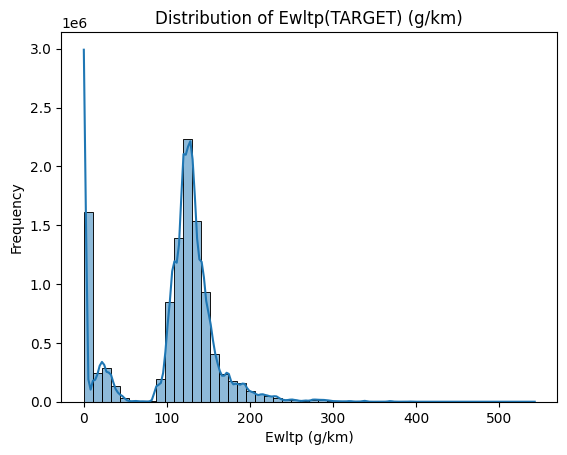

In [74]:
sns.histplot(df['Ewltp (g/km)'], bins=50, kde=True)
plt.xlabel('Ewltp (g/km)')
plt.ylabel('Frequency') 
plt.title('Distribution of Ewltp(TARGET) (g/km)')
plt.show()  

**2.Correlation Heatmap (NUMERICAL ONLY)**  : 
 

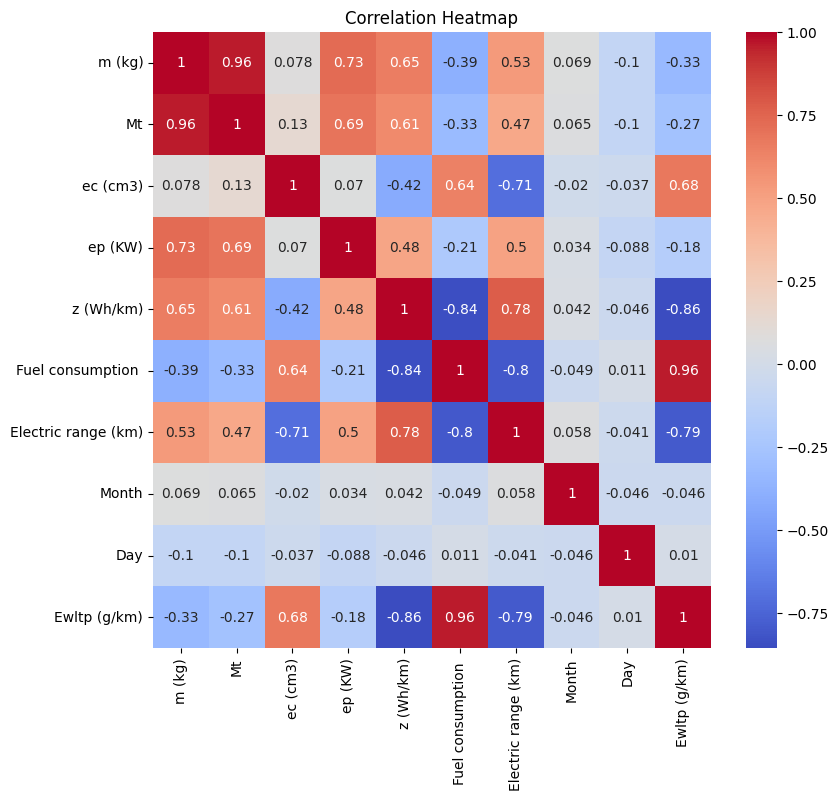

In [75]:
#make the size a bit more bigger
plt.figure(figsize=(9, 8))
corr = df[numerical_features + [target]].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()  

**HeatMap updates**
 
- Fuel consumption +0.96, Very good /perfect corr — more fuel = more CO2. Risk of data leakage  ***to be checked***
- z (Wh/km)-0.86, Strong negative — EVs consume electricity, emit 0 CO2 [***strong negative correlation***]
- Electric range (km)-0.79, Longer EV range → lower emissions ( can be EV or hybrid ) [***strong negative correlation***]
- ec (cm3)+0.68 , Bigger engine = more emissions (ICE logic)
- m (kg)-0.33 , Heavier cars slightly lower :— because heavy EVs pull the mean down
- Mt -0.27 Same logic as mass ( m -kg )
- ep (KW)-0.18 Weak — EVs have high power but 0 emissions, 
- Month-0.046, Nearly zero — registration month irrelevant to emissions so consider dropping *** to be checked***
- Day+0.01, Nearly  Zero — drop this feature as well

**Fuel consumption** : 0.96  : Dominant predictor , almost a proxy for our Target. Because both are measured together. Strongly suggests  that Fuel consumption might be calculated from Ewltp or vice versa since both are regulatory measurement metrics.
   - Risk: Using it directly causes target leakage — model memorizes rather than learns physics or from other variables
   - ***Line of action : Investigate  the effect with and without Fuel consumption.***

**Multicollinearity checks** :
  - m (kg) ↔ Mt : ***0.96*** , ***Drop Mt — near-duplicate of vehicle mass***
  - z (Wh/km) ↔ Fuel consumption: -0.84 ,Expected — EVs have high z, zero fuel
  - z (Wh/km) ↔ Electric range: +0.78, Expected — more energy stored = more range
  - Fuel consumption ↔ Electric range -0.80: Expected — EVs don't use fuel
  - m (kg) ↔ ep (KW) 0.73 : Heavier cars tend to have more power 
  - m (kg) ↔ z (Wh/km) 0.65: Heavier EVs need more energy


**Mass and Power Are Confounded**:
Negative correlations for m (kg) and ep (KW) with the Target are counterintuitive—heavier vehicles should burn more fuel. This reversal likely occurs because:

 - EVs are heavy but have zero emissions → here correlation flips
 - Modern efficient engines in lighter cars also reduce emissions
 - Suggesting : Separation of  EV and ICE separately, or use stratified modeling ( need to check ***stratified modeling***)

**Conclusons** : Mirror correlations bewteen ICE & EVs suggets the clear demarkation of EV / ICE split . This shows that our feature of ***vehicle_type'** is dominating variable for the split.<br>
                  Strong negative correlations , confirm the Bimodal distribution of the target. 

**Action points** : Drop m (kg) , Month , Day  + Split data with and without Fuel consumption


**3.Countplots for Key Categorical variables** : 
 - ***cleary shows the ICE domination and the imbalance check as well***

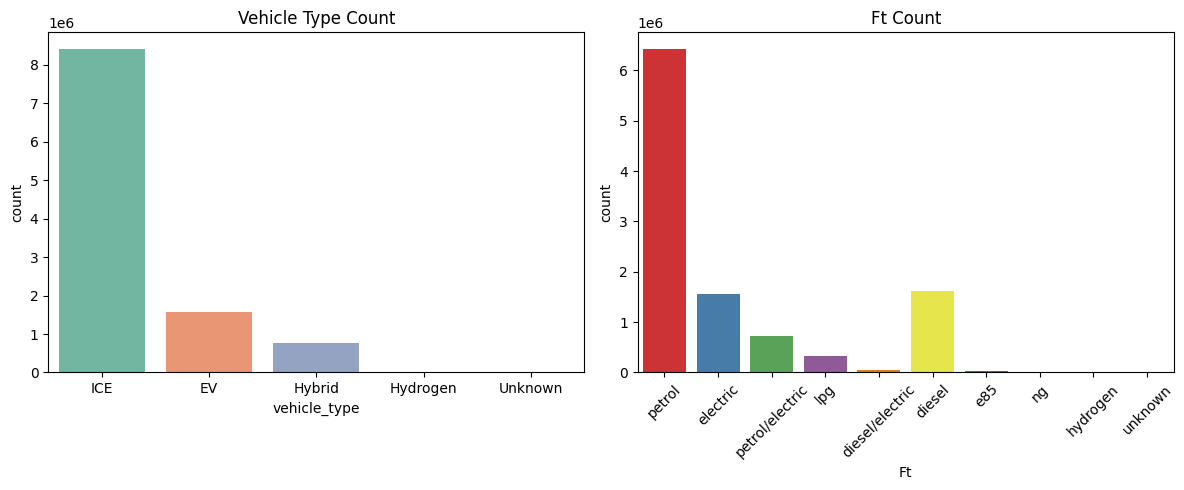

In [76]:

#  Countplot for key  categorical features : to check the imbalance of the dataset variables
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.countplot(x='vehicle_type', data=df, hue='vehicle_type', palette='Set2', legend=False)
plt.title('Vehicle Type Count')

plt.subplot(1,2,2)
sns.countplot(x='Ft', data=df, hue='Ft', palette='Set1', legend=False)
plt.title('Ft Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**4. BOXPLOT of Target vs Category**   :   
 - Shows EV --> with 0 emissions 
 - ICE --> high emissions

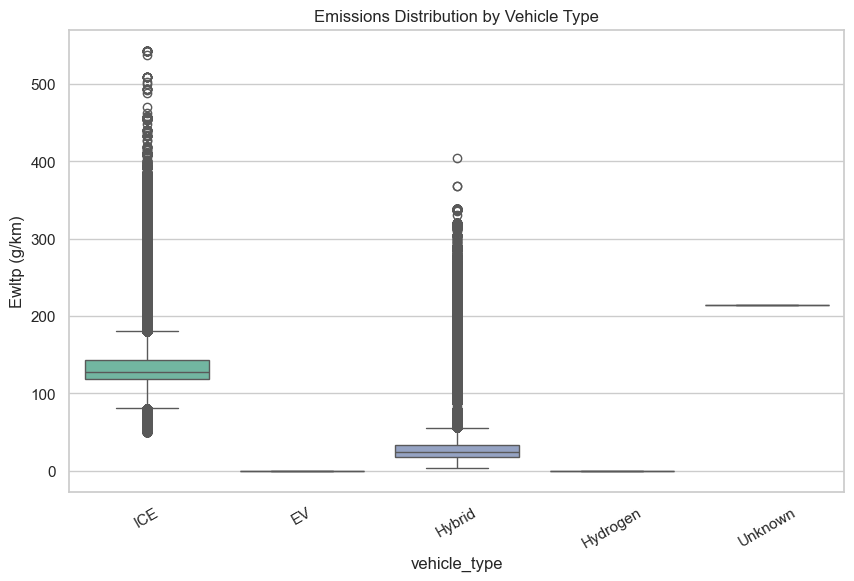

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.set(style="whitegrid")

sns.boxplot(
    x='vehicle_type',
    y='Ewltp (g/km)',
    hue='vehicle_type',
    data=df,
    palette='Set2',
    legend=False
)

plt.title('Emissions Distribution by Vehicle Type')
plt.xticks(rotation=30)
plt.show()

**5.Scatter-Plot : Engine Capacity vs Emissions (coloured by vehicle_type)**
- ***Shows "More  ec(engine capacity) --> more cc --> more Co2 emissions"***

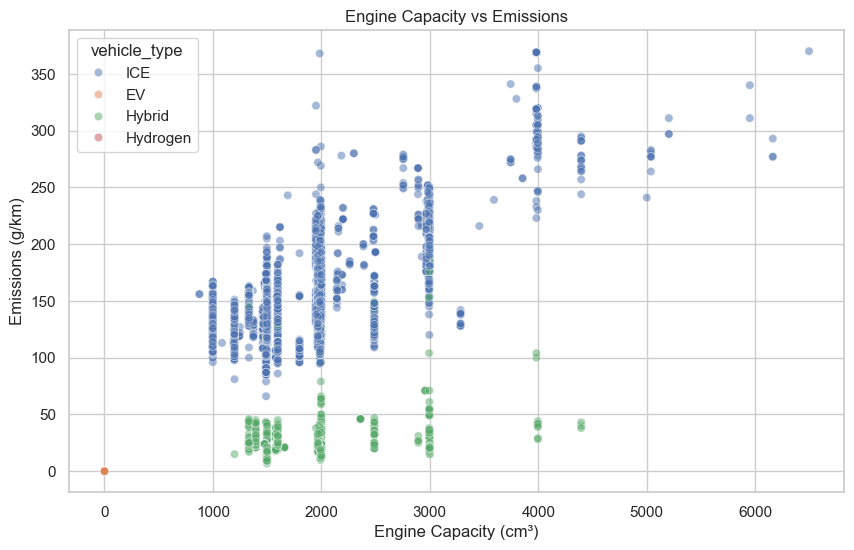

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sample to avoid overplotting
sample = df.sample(20000, random_state=42)

plt.figure(figsize=(10,6))
sns.set(style="whitegrid")

sns.scatterplot(
    x='ec (cm3)',
    y='Ewltp (g/km)',
    hue='vehicle_type',
    data=sample,
    alpha=0.5
)

plt.title('Engine Capacity vs Emissions')
plt.xlabel('Engine Capacity (cm³)')
plt.ylabel('Emissions (g/km)')

plt.show()

**6.Pairplots: shows the linear and non linear distribution of the dataset , along with the key vehicle type split**

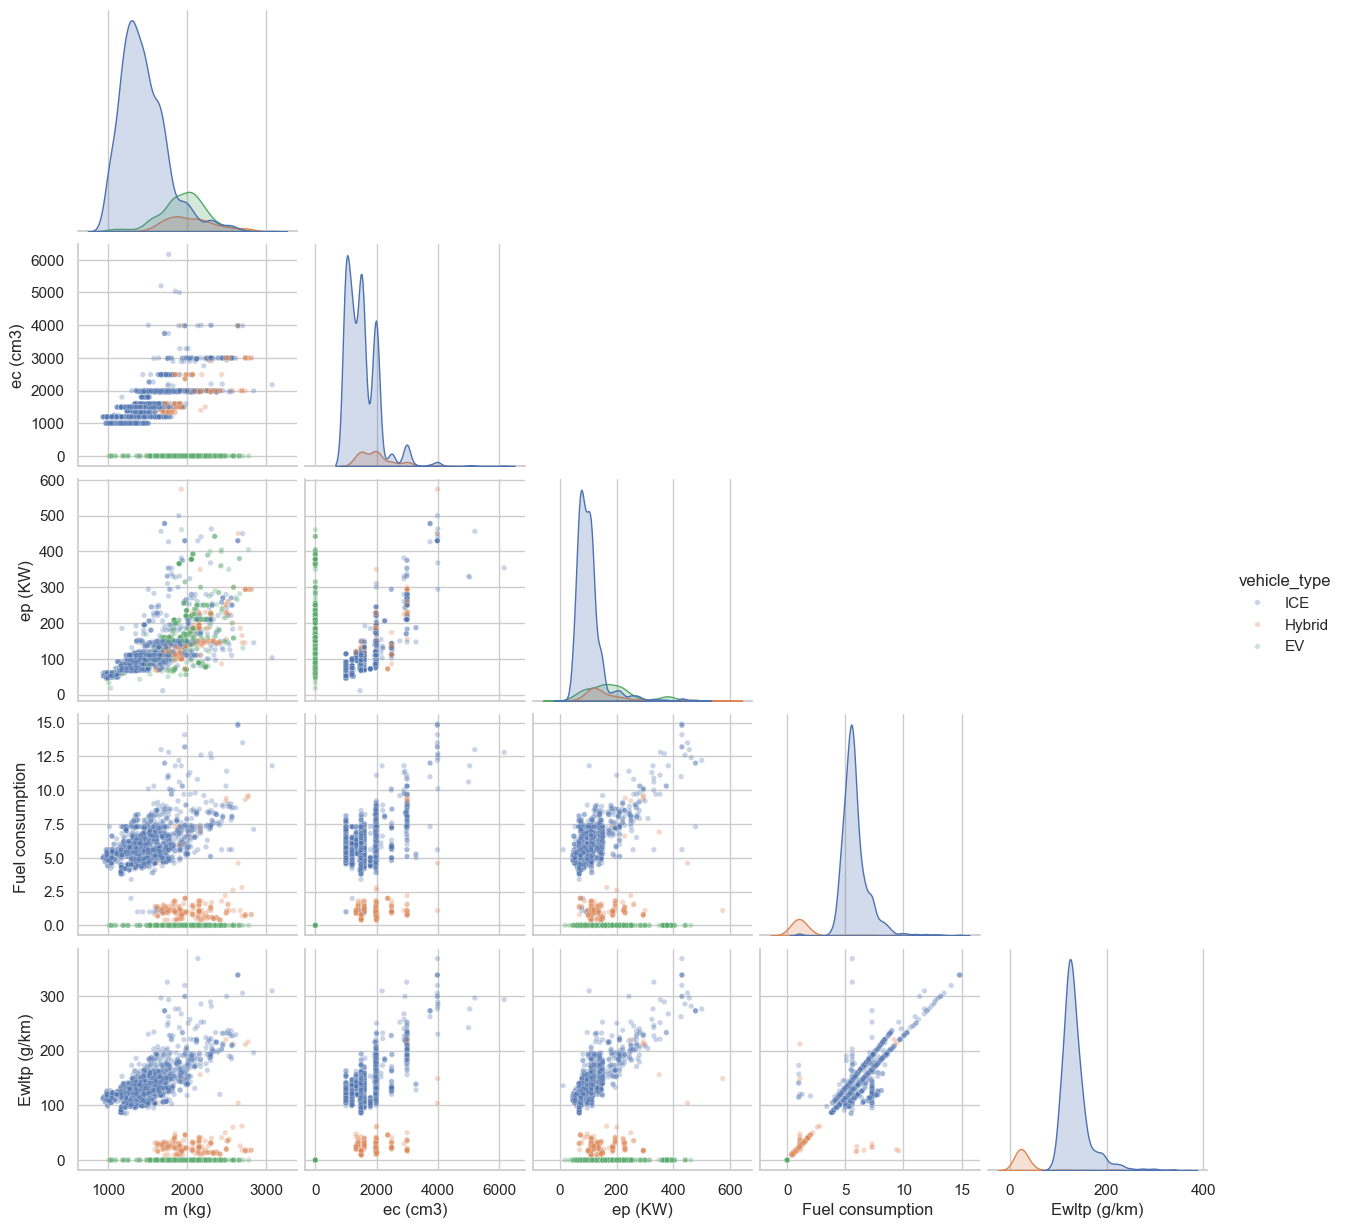

In [83]:
# Why: Spot non-linear relationships before choosing model family
key_cols = ['m (kg)', 'ec (cm3)', 'ep (KW)', 'Fuel consumption ', 'Ewltp (g/km)']
sns.pairplot(df[key_cols + ['vehicle_type']].dropna().sample(3000), hue='vehicle_type', diag_kind='kde',corner=True,plot_kws={'alpha': 0.3, 's': 15})

**7.COUNT PLOTS for key Categorical features**

In [ ]:
categorical_features = [
    'Country', 
    'Mh', 
    'Va', 
    'Mk', 
    'Cn', 
    'Ct', 
    'Ft', 
    'Fm', 
    'IT', 
    'vehicle_type', 
    'ech_clean'
]

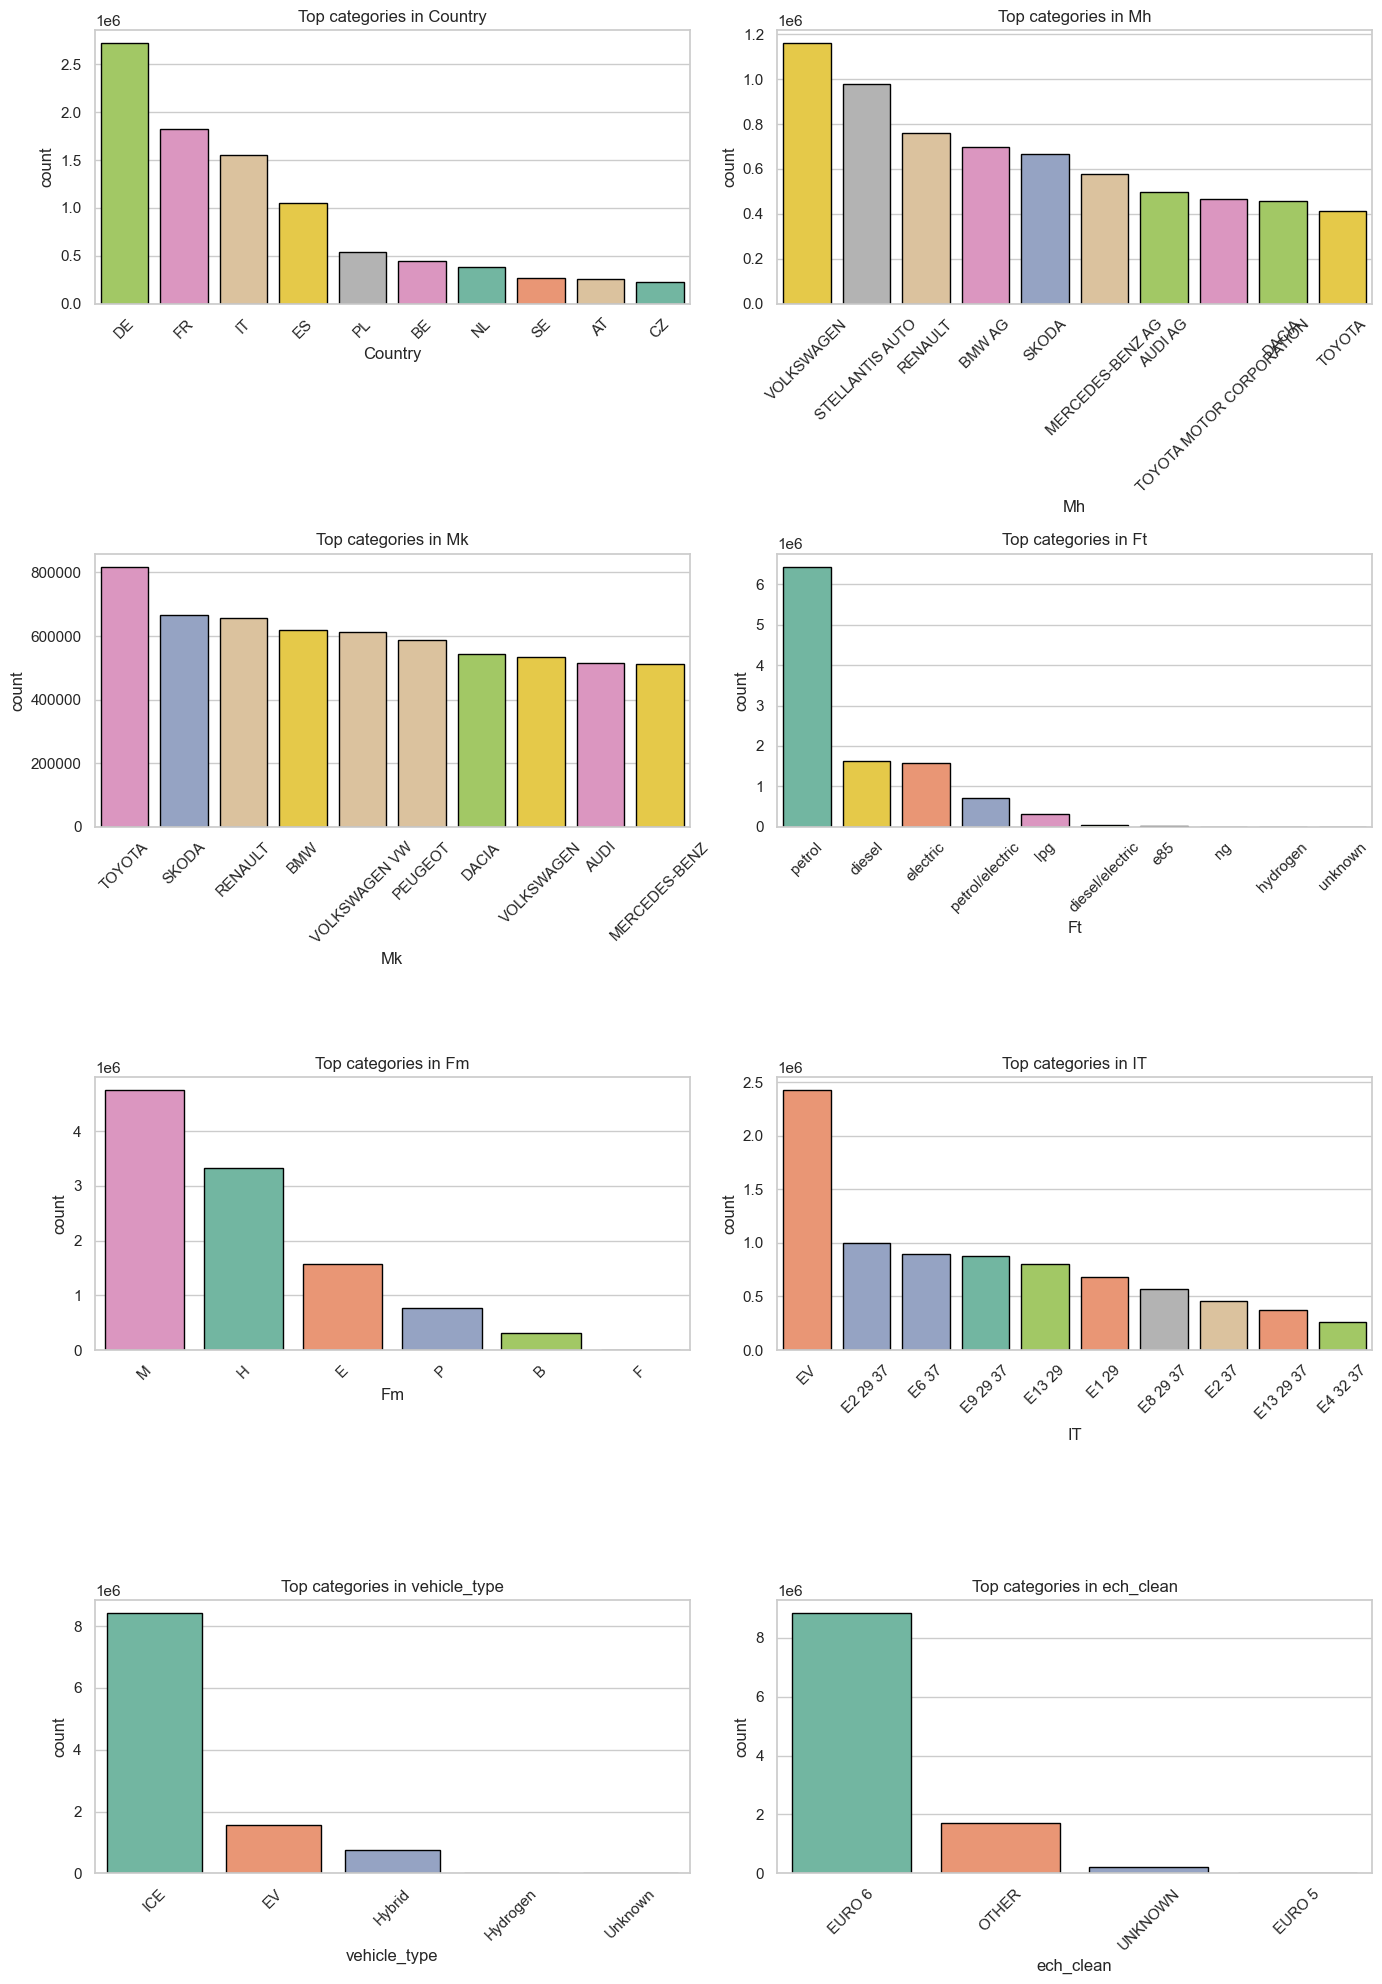

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt
import math

categorical_features = [
    'Country','Mh','Mk','Ft','Fm','IT','vehicle_type','ech_clean'
]

sns.set(style="whitegrid")

n_cols = 2
n_rows = math.ceil(len(categorical_features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    top_vals = df1[col].value_counts().index[:10]

    sns.countplot(
        data=df1,
        x=col,
        order=top_vals,
        hue=col,                 # future-proof coloring
        palette='Set2',
        edgecolor='black',
        legend=False,
        ax=axes[i]
    )

    axes[i].set_title(f"Top categories in {col}")
    axes[i].tick_params(axis='x', rotation=45)

# Remove empty subplots if any
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# From the anaylsis of Correlation & Plots :
 ***We intend to drop some columns such as   month and day columns and m (kg)***

In [94]:
# list column names
df.columns

Index(['Country', 'Mh', 'Va', 'Mk', 'Cn', 'Ct', 'm (kg)', 'Mt', 'Ewltp (g/km)',
       'Ft', 'Fm', 'ec (cm3)', 'ep (KW)', 'z (Wh/km)', 'IT',
       'Fuel consumption ', 'Electric range (km)', 'Month', 'Day',
       'vehicle_type', 'ech_clean'],
      dtype='str')

# Copy of the Dataset

In [95]:
# copy the dataframe
df_model = df.copy()

In [96]:
# drop m (kg)
df_model.drop(columns=["m (kg)"], inplace=True)

# ---------------------------------------------------------------------------------------------------

# ---------------------------------------------------------------------------------------------------

# ---------------------------------------------------------------------------------------------------

# Scaling and Encoding #
- Numerical features :
    - Month & Day - Ordinal / Cyclic :- Encoding type shall be 
    - Rest of the Numerical features :- Continous type

    


In [99]:
df_model.columns = df_model.columns.str.strip()

# Train - Test Split

In [102]:
target = 'Ewltp (g/km)'

train = df_model[df_model['Month'] <= 9]
test  = df_model[df_model['Month'] > 9]

X_train = train.drop(columns=[target])
y_train = train[target]

X_test = test.drop(columns=[target])
y_test = test[target]

# Encoding

In [103]:
# cyclic encoding for month and day 

for df_ in [X_train, X_test]:
    df_['month_sin'] = np.sin(2 * np.pi * df_['Month'] / 12)
    df_['month_cos'] = np.cos(2 * np.pi * df_['Month'] / 12)
    df_['day_sin']   = np.sin(2 * np.pi * df_['Day'] / 31)
    df_['day_cos']   = np.cos(2 * np.pi * df_['Day'] / 31)

    df_.drop(['Month', 'Day'], axis=1, inplace=True)

# Drop noisy columns
drop_cols = ['Va', 'Cn']
X_train.drop(columns=drop_cols, inplace=True)
X_test.drop(columns=drop_cols, inplace=True)

# 2 datasets to be trained & checked 
- WITH Fuel Consumption
- WITHOUT Fuel Consumption

**With Fuel Consumption**

In [107]:
numerical_A = [
    'm (kg)', 'Mt', 'ec (cm3)', 'ep (KW)',
    'z (Wh/km)', 'Fuel consumption', 'Electric range (km)',
    'month_sin', 'month_cos', 'day_sin', 'day_cos'
]

**Without Fuel Consumption**

In [108]:
numerical_B = [
    'm (kg)', 'Mt', 'ec (cm3)', 'ep (KW)',
    'z (Wh/km)', 'Electric range (km)',
    'month_sin', 'month_cos', 'day_sin', 'day_cos'
]

**High & Low Cadinality Categorical Groups**

In [109]:
low_cardinality = ['Ct', 'Ft', 'Fm', 'vehicle_type', 'ech_clean']
high_cardinality = ['Country', 'Mh', 'Mk', 'IT']

# Scaling 

**Scaling - Numerical**

In [110]:
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline

num_pipeline = Pipeline([
    ('scaler', RobustScaler())
])

**One-Hot ( Low-cardinality)**

In [111]:
from sklearn.preprocessing import OneHotEncoder

cat_low_pipeline = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [112]:
from category_encoders import TargetEncoder

cat_high_pipeline = Pipeline([
    ('target_enc', TargetEncoder())
])

ModuleNotFoundError: No module named 'category_encoders'

# ---------------------------------------------------------------------------------------------------

# ---------------------------------------------------------------------------------------------------

# ---------------------------------------------------------------------------------------------------